# 1. Cài đặt & Import

In [1]:
# Cài đặt thư viện gensim để tải FastText embeddings
!pip install gensim

# Import thư viện chung
import pandas as pd
import numpy as np
import os
import json
from tqdm.auto import tqdm
import warnings

# Thư viện cho Baseline 1 (SVM)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score, accuracy_score

# Thư viện cho Baseline 2 (BiLSTM)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from gensim.models import KeyedVectors
from collections import Counter

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 52.4 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.0 which is incompatible.
imbalanced-learn 0.13.0 requires scikit-learn<2,>=1.3.2, but you have scikit-learn 1.2.2 which is incompatible.
plotnine 0.14.5 requires matplotlib>=3.8.0, but you have matplotlib 3.7.2 which is incompatible.
umap-

# 2. Tải Dữ liệu đã Xử lý

In [2]:
# Đường dẫn tới các file đã xử lý từ notebook 01
KAGGLE_WORKING_PATH = '/kaggle/input/tmg-processed'
TRAIN_PATH = os.path.join(KAGGLE_WORKING_PATH, 'train_processed.csv')
VAL_PATH = os.path.join(KAGGLE_WORKING_PATH, 'val_processed.csv')
TEST_PATH = os.path.join(KAGGLE_WORKING_PATH, 'test_processed.csv')

# Đọc file
try:
    train_df = pd.read_csv(TRAIN_PATH)
    val_df = pd.read_csv(VAL_PATH)
    test_df = pd.read_csv(TEST_PATH)
    
    print(f"Tải {len(train_df)} mẫu train, {len(val_df)} mẫu val, {len(test_df)} mẫu test.")
except FileNotFoundError:
    print("Lỗi: Không tìm thấy file ..._processed.csv. Bạn cần chạy notebook 01 trước.")
    # Bạn có thể dừng notebook ở đây nếu muốn

# Xử lý các giá trị NaN (rất quan trọng)
train_df['text_processed'] = train_df['text_processed'].fillna("")
val_df['text_processed'] = val_df['text_processed'].fillna("")
test_df['text_processed'] = test_df['text_processed'].fillna("")

Tải 23033 mẫu train, 3302 mẫu val, 6609 mẫu test.


In [3]:
train_df

,text,sentiment,classification,text_processed,sentences,num_sentences,text_length,num_words,split
0,em xin chào các anh chị em em là sinh viên vừa...,0.0,2.0,em xin chào các anh chị em em là sinh viên vừa...,['em xin chào các anh chị em em là sinh viên v...,1,486,119,train
1,xây dựng mô hình sư phạm chuẩn mực sáng tạo ti...,0.0,2.0,xây dựng mô hình sư phạm chuẩn mực sáng tạo ti...,['xây dựng mô hình sư phạm chuẩn mực sáng tạo ...,1,56,13,train
2,sao lại ghét cái kiểu làm sai xong khóc lóc ăn...,2.0,3.0,sao lại ghét cái kiểu làm sai xong khóc lóc ăn...,['sao lại ghét cái kiểu làm sai xong khóc lóc ...,1,337,78,train
3,chào thầy đăng ký học ghép . môn học hiện hệ t...,0.0,2.0,chào thầy đăng ký học ghép . môn học hiện hệ t...,['chào thầy đăng ký học ghép . môn học hiện hệ...,1,171,40,train
4,con bé vẫn hoang mang lắm .,2.0,3.0,con bé vẫn hoang mang lắm .,['con bé vẫn hoang mang lắm .'],1,27,7,train
...,...,...,...,...,...,...,...,...,...
23028,tùy syt xưa thành phố hồ chí minh á . giờ văn ...,0.0,1.0,tùy syt xưa thành phố hồ chí minh á . giờ văn ...,['tùy syt xưa thành phố hồ chí minh á . giờ vă...,1,95,23,train
23029,mình nghĩ là nên học ielts hơn vì nó có ích ch...,0.0,2.0,mình nghĩ là nên học ielts hơn vì nó có ích ch...,['mình nghĩ là nên học ielts hơn vì nó có ích ...,1,100,26,train
23030,giỏi lắm là 7 8 bài 1 năm chứ cả mấy chục bài ...,0.0,3.0,giỏi lắm là <num> <num> bài <num> năm chứ cả m...,['giỏi lắm là <num> <num> bài <num> năm chứ cả...,1,75,18,train
23031,kiếp nạn số 82 vui nhộn không kém .,1.0,3.0,kiếp nạn số <num> vui nhộn không kém .,['kiếp nạn số <num> vui nhộn không kém .'],1,38,9,train


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23033 entries, 0 to 23032
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   text            23033 non-null  object 
 1   sentiment       23033 non-null  float64
 2   classification  23033 non-null  float64
 3   text_processed  23033 non-null  object 
 4   sentences       23033 non-null  object 
 5   num_sentences   23033 non-null  int64  
 6   text_length     23033 non-null  int64  
 7   num_words       23033 non-null  int64  
 8   split           23033 non-null  object 
dtypes: float64(2), int64(3), object(4)
memory usage: 1.6+ MB


In [5]:
val_df

,text,sentiment,classification,text_processed,sentences,num_sentences,text_length,num_words,split
0,thực sự đang có quá nhiều thiệt thòi cho các e...,2.0,2.0,thực sự đang có quá nhiều thiệt thòi cho các e...,['thực sự đang có quá nhiều thiệt thòi cho các...,1,191,47,val
1,hên là học lớp 6 rồi .,0.0,3.0,hên là học lớp <num> rồi .,['hên là học lớp <num> rồi .'],1,26,7,val
2,capcut giật giật khoe trúng tuyển oi .,0.0,3.0,capcut giật giật khoe trúng tuyển oi .,['capcut giật giật khoe trúng tuyển oi .'],1,38,8,val
3,việt học chức cử nhân giỏi . được ngang quy si...,1.0,2.0,việt học chức cử nhân giỏi . được ngang quy si...,['việt học chức cử nhân giỏi . được ngang quy ...,1,68,16,val
4,nếu trời mưa thì có thể đi ngang cái cống sức ...,2.0,3.0,nếu trời mưa thì có thể đi ngang cái cống sức ...,['nếu trời mưa thì có thể đi ngang cái cống sứ...,1,122,30,val
...,...,...,...,...,...,...,...,...,...
3297,yah ngồi lại nói chuyện với nhau thôi em nếu m...,2.0,3.0,yah ngồi lại nói chuyện với nhau thôi em nếu m...,['yah ngồi lại nói chuyện với nhau thôi em nếu...,1,67,16,val
3298,tuyển dụng giảng viên kỹ thuật hàng điện tử . ...,0.0,5.0,tuyển dụng giảng viên kỹ thuật hàng điện tử . ...,['tuyển dụng giảng viên kỹ thuật hàng điện tử ...,1,226,49,val
3299,học lấy chứng chỉ ở đâu vậy bạn . có tốn tiền ...,2.0,2.0,học lấy chứng chỉ ở đâu vậy bạn . có tốn tiền ...,['học lấy chứng chỉ ở đâu vậy bạn . có tốn tiề...,1,90,22,val
3300,sao hỏi toàn môn mình học thế .,1.0,2.0,sao hỏi toàn môn mình học thế .,['sao hỏi toàn môn mình học thế .'],1,31,8,val


In [6]:
val_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3302 entries, 0 to 3301
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   text            3302 non-null   object 
 1   sentiment       3302 non-null   float64
 2   classification  3302 non-null   float64
 3   text_processed  3302 non-null   object 
 4   sentences       3302 non-null   object 
 5   num_sentences   3302 non-null   int64  
 6   text_length     3302 non-null   int64  
 7   num_words       3302 non-null   int64  
 8   split           3302 non-null   object 
dtypes: float64(2), int64(3), object(4)
memory usage: 232.3+ KB


In [7]:
test_df

,text,sentiment,classification,text_processed,sentences,num_sentences,text_length,num_words,split
0,từ động chạm hơi nhiều người .,0.0,3.0,từ động chạm hơi nhiều người .,['từ động chạm hơi nhiều người .'],1,30,7,test
1,dạ chắc để bạn tự liên lạc các thầy cô bên trư...,0.0,2.0,dạ chắc để bạn tự liên lạc các thầy cô bên trư...,['dạ chắc để bạn tự liên lạc các thầy cô bên t...,1,137,33,test
2,sợ nặng thì bỏ xắc suất thống kê ra cho điện t...,2.0,2.0,sợ nặng thì bỏ xắc suất thống kê ra cho điện t...,['sợ nặng thì bỏ xắc suất thống kê ra cho điện...,1,100,26,test
3,tiếc hầy em 2003 phỉ .,2.0,3.0,tiếc hầy em <num> phỉ .,['tiếc hầy em <num> phỉ .'],1,23,6,test
4,ai cũng cần phải từng trải để trưởng thành mà ...,0.0,3.0,ai cũng cần phải từng trải để trưởng thành mà ...,['ai cũng cần phải từng trải để trưởng thành m...,1,73,17,test
...,...,...,...,...,...,...,...,...,...
6604,nghĩ cho các em với các bạn đi sau mà mang hàn...,0.0,3.0,nghĩ cho các em với các bạn đi sau mà mang hàn...,['nghĩ cho các em với các bạn đi sau mà mang h...,1,64,16,test
6605,giờ không vào được web thì đăng kí kiểu gì .,0.0,8.0,giờ không vào được web thì đăng kí kiểu gì .,['giờ không vào được web thì đăng kí kiểu gì .'],1,44,11,test
6606,woww lâm top vợ chồng .,0.0,3.0,woww lâm top vợ chồng .,['woww lâm top vợ chồng .'],1,23,6,test
6607,xuân gắn liền k êi .,0.0,3.0,xuân gắn liền không êi .,['xuân gắn liền không êi .'],1,24,6,test


In [8]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6609 entries, 0 to 6608
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   text            6609 non-null   object 
 1   sentiment       6609 non-null   float64
 2   classification  6609 non-null   float64
 3   text_processed  6609 non-null   object 
 4   sentences       6609 non-null   object 
 5   num_sentences   6609 non-null   int64  
 6   text_length     6609 non-null   int64  
 7   num_words       6609 non-null   int64  
 8   split           6609 non-null   object 
dtypes: float64(2), int64(3), object(4)
memory usage: 464.8+ KB


# 3. Chuẩn bị Dữ liệu (Tách X, y)

In [9]:
# Tách dữ liệu
X_train = train_df['text_processed']
y_train_sent = train_df['sentiment']
y_train_topic = train_df['classification']

X_val = val_df['text_processed']
y_val_sent = val_df['sentiment']
y_val_topic = val_df['classification']

X_test = test_df['text_processed']
y_test_sent = test_df['sentiment']
y_test_topic = test_df['classification']

# Dictionary để lưu kết quả
baseline_results = {}

# Baseline 1: TF-IDF + Linear SVM

# 4. Vectorization (TF-IDF)

In [10]:
print("Đang huấn luyện TF-IDF Vectorizer...")
# Sử dụng n-gram (1, 2) để bắt được các cụm từ
vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Kích thước TF-IDF matrix (Train): {X_train_tfidf.shape}")

Đang huấn luyện TF-IDF Vectorizer...
Kích thước TF-IDF matrix (Train): (23033, 20000)


# 5. Huấn luyện & Đánh giá (SVM - Sentiment)

In [11]:
# (MỚI) Import các thư viện visualize và metrics cần thiết
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os # Cần cho figures_dir

In [12]:
# (MỚI) Định nghĩa lại đường dẫn lưu figure, giống như notebook 01
KAGGLE_WORKING_PATH = '/kaggle/working/'
FIGURES_PATH = os.path.join(KAGGLE_WORKING_PATH, 'figures')
os.makedirs(FIGURES_PATH, exist_ok=True)

In [13]:
print("\n--- Baseline 1: SVM (Sentiment) ---")
# class_weight='balanced' để xử lý class imbalance 
svm_sentiment = LinearSVC(class_weight='balanced', dual=True, max_iter=2000)
svm_sentiment.fit(X_train_tfidf, y_train_sent)

# --- Đánh giá trên tập Validation ---
preds_val_sent = svm_sentiment.predict(X_val_tfidf)
# Tính F1-macro theo yêu cầu 
f1_val_sent_svm = f1_score(y_val_sent, preds_val_sent, average='macro')

print("--- SVM Sentiment (Validation) ---")
print(classification_report(y_val_sent, preds_val_sent, digits=4))
print(f"Validation F1-macro (Sentiment): {f1_val_sent_svm:.4f}")

# Lưu kết quả validation (cập nhật tên key)
baseline_results['svm_sentiment_val'] = f1_val_sent_svm


--- Baseline 1: SVM (Sentiment) ---
--- SVM Sentiment (Validation) ---
              precision    recall  f1-score   support

         0.0     0.8630    0.8652    0.8641      2278
         1.0     0.6115    0.6379    0.6244       417
         2.0     0.6121    0.5992    0.6056       524
         3.0     0.7429    0.6265    0.6797        83

    accuracy                         0.7883      3302
   macro avg     0.7073    0.6822    0.6935      3302
weighted avg     0.7884    0.7883    0.7882      3302

Validation F1-macro (Sentiment): 0.6935


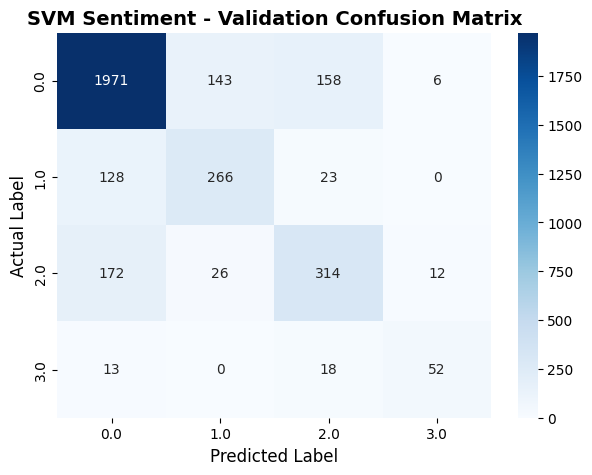

In [14]:
# --- (MỚI) Vẽ Validation Confusion Matrix ---
cm_val = confusion_matrix(y_val_sent, preds_val_sent)
# Lấy nhãn tự động từ dữ liệu (ví dụ: [0.0, 1.0, 2.0, 3.0])
class_labels = sorted(y_val_sent.unique()) 

plt.figure(figsize=(7, 5))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('SVM Sentiment - Validation Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.savefig(os.path.join(FIGURES_PATH, 'svm_sentiment_validation_cm.png'), dpi=300)
plt.show()

In [15]:
# --- Đánh giá trên tập Test ---
print("\n--- SVM Sentiment (Test) ---")
preds_test_sent = svm_sentiment.predict(X_test_tfidf)
f1_test_sent_svm = f1_score(y_test_sent, preds_test_sent, average='macro')

print(classification_report(y_test_sent, preds_test_sent, digits=4))
print(f"Test F1-macro (Sentiment): {f1_test_sent_svm:.4f}")

# Lưu kết quả test
baseline_results['svm_sentiment_test'] = f1_test_sent_svm


--- SVM Sentiment (Test) ---
              precision    recall  f1-score   support

         0.0     0.8568    0.8677    0.8622      4557
         1.0     0.6433    0.6170    0.6299       833
         2.0     0.5921    0.5847    0.5883      1045
         3.0     0.7546    0.7069    0.7300       174

    accuracy                         0.7871      6609
   macro avg     0.7117    0.6941    0.7026      6609
weighted avg     0.7853    0.7871    0.7861      6609

Test F1-macro (Sentiment): 0.7026


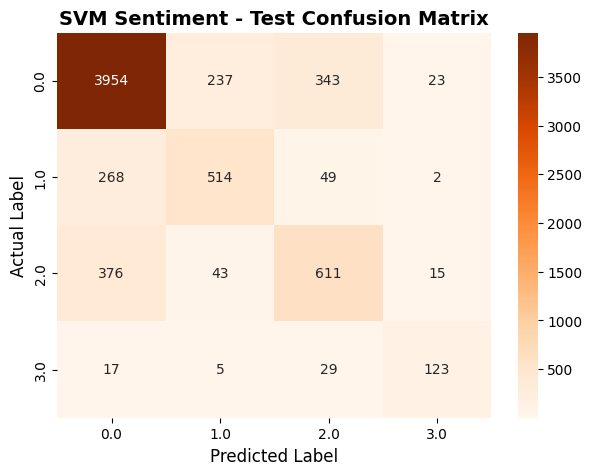


✓ Đã thêm Confusion Matrix Heatmaps.


In [16]:
# --- (MỚI) Vẽ Test Confusion Matrix ---
cm_test = confusion_matrix(y_test_sent, preds_test_sent)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('SVM Sentiment - Test Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.savefig(os.path.join(FIGURES_PATH, 'svm_sentiment_test_cm.png'), dpi=300)
plt.show()

print("\n✓ Đã thêm Confusion Matrix Heatmaps.")

# 5.2. Huấn luyện SVM - Topic

In [17]:
# (MỚI) Cell 17: Huấn luyện & Đánh giá (SVM - Topic)
print("\n--- Baseline 1: SVM (Topic) ---")
# class_weight='balanced' để xử lý class imbalance 
svm_topic = LinearSVC(class_weight='balanced', dual=True, max_iter=2000)
svm_topic.fit(X_train_tfidf, y_train_topic)

# --- Đánh giá trên tập Validation ---
preds_val_topic = svm_topic.predict(X_val_tfidf)
# Tính F1-macro theo yêu cầu 
f1_val_topic_svm = f1_score(y_val_topic, preds_val_topic, average='macro')

print("--- SVM Topic (Validation) ---")
print(classification_report(y_val_topic, preds_val_topic, digits=4))
print(f"Validation F1-macro (Topic): {f1_val_topic_svm:.4f}")

# Lưu kết quả validation
baseline_results['svm_topic_val'] = f1_val_topic_svm


--- Baseline 1: SVM (Topic) ---
--- SVM Topic (Validation) ---
              precision    recall  f1-score   support

         0.0     0.6222    0.7000    0.6588        40
         1.0     0.4623    0.5385    0.4975        91
         2.0     0.8220    0.7814    0.8012      1052
         3.0     0.8382    0.8417    0.8399      1440
         4.0     0.5593    0.6371    0.5957       237
         5.0     0.5306    0.6420    0.5810        81
         6.0     0.4490    0.4459    0.4475       148
         7.0     0.5143    0.4615    0.4865        78
         8.0     0.4237    0.3676    0.3937        68
         9.0     0.6885    0.6269    0.6563        67

    accuracy                         0.7520      3302
   macro avg     0.5910    0.6043    0.5958      3302
weighted avg     0.7558    0.7520    0.7532      3302

Validation F1-macro (Topic): 0.5958


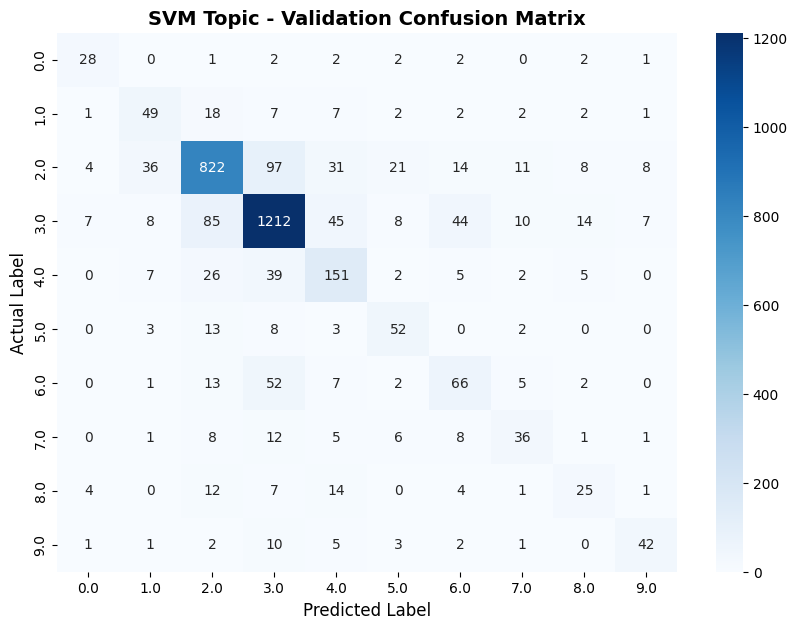

In [18]:
# --- (MỚI) Vẽ Validation Confusion Matrix ---
cm_val_topic = confusion_matrix(y_val_topic, preds_val_topic)
# Lấy nhãn tự động
class_labels_topic = sorted(y_val_topic.unique()) 

plt.figure(figsize=(10, 7)) # Tăng kích thước vì có nhiều lớp topic
sns.heatmap(cm_val_topic, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels_topic, yticklabels=class_labels_topic)
plt.title('SVM Topic - Validation Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.savefig(os.path.join(FIGURES_PATH, 'svm_topic_validation_cm.png'), dpi=300)
plt.show()

In [19]:
# --- Đánh giá trên tập Test ---
print("\n--- SVM Topic (Test) ---")
preds_test_topic = svm_topic.predict(X_test_tfidf)
f1_test_topic_svm = f1_score(y_test_topic, preds_test_topic, average='macro')

print(classification_report(y_test_topic, preds_test_topic, digits=4))
print(f"Test F1-macro (Topic): {f1_test_topic_svm:.4f}")

# Lưu kết quả test
baseline_results['svm_topic_test'] = f1_test_topic_svm


--- SVM Topic (Test) ---
              precision    recall  f1-score   support

         0.0     0.4368    0.4524    0.4444        84
         1.0     0.3791    0.4372    0.4061       183
         2.0     0.8345    0.7960    0.8148      2103
         3.0     0.8306    0.8347    0.8326      2879
         4.0     0.5442    0.5970    0.5694       474
         5.0     0.6069    0.6442    0.6250       163
         6.0     0.4676    0.4597    0.4636       298
         7.0     0.4167    0.3871    0.4013       155
         8.0     0.3987    0.4599    0.4271       137
         9.0     0.6855    0.6391    0.6615       133

    accuracy                         0.7456      6609
   macro avg     0.5601    0.5707    0.5646      6609
weighted avg     0.7503    0.7456    0.7476      6609

Test F1-macro (Topic): 0.5646


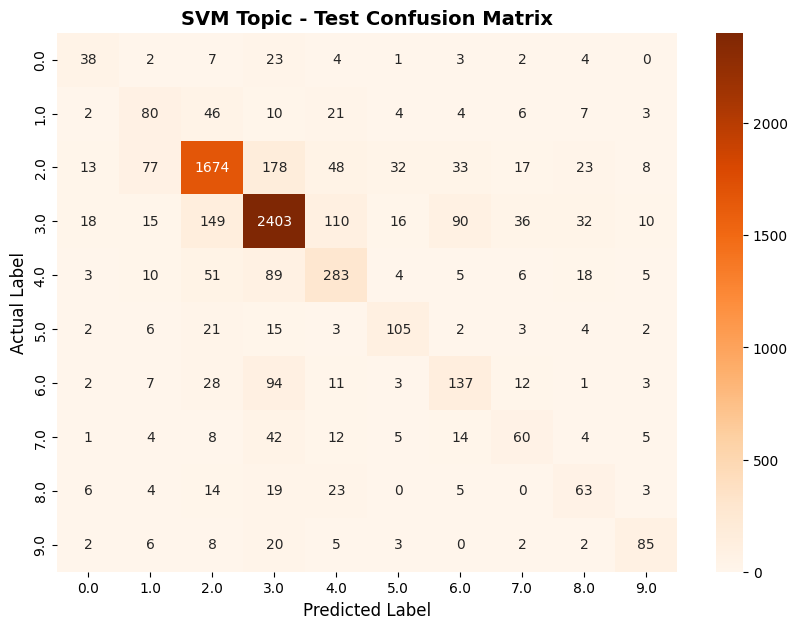


✓ Đã thêm Confusion Matrix Heatmaps cho Topic.


In [20]:
# --- (MỚI) Vẽ Test Confusion Matrix ---
cm_test_topic = confusion_matrix(y_test_topic, preds_test_topic)

plt.figure(figsize=(10, 7))
sns.heatmap(cm_test_topic, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=class_labels_topic, yticklabels=class_labels_topic)
plt.title('SVM Topic - Test Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.savefig(os.path.join(FIGURES_PATH, 'svm_topic_test_cm.png'), dpi=300)
plt.show()

print("\n✓ Đã thêm Confusion Matrix Heatmaps cho Topic.")

# Baseline 2: BiLSTM + Pre-trained Embeddings

# 7. Tải Embeddings (FastText)

In [21]:
# --- LỰA CHỌN 1: Thêm dataset "cc.vi.300.vec" vào Kaggle ---
# (Giả sử bạn đã thêm và nó nằm ở /kaggle/input/ccvi300vec/cc.vi.300.vec)
EMBED_PATH = "/kaggle/input/fasttext-vietnamese-word-vectors-full/cc.vi.300.vec"
EMBED_DIM = 300

# Tải embeddings vào bộ nhớ (có thể mất vài phút)
print("Đang tải embeddings vào Gensim...")
try:
    word_vectors = KeyedVectors.load_word2vec_format(EMBED_PATH)
    print(f"Tải thành công {len(word_vectors.key_to_index)} từ.")
except Exception as e:
    print(f"Lỗi: Không thể tải file embedding tại {EMBED_PATH}. Lỗi: {e}")
    print("Vui lòng thêm dataset 'cc.vi.300.vec' vào notebook.")
    word_vectors = None # Đặt cờ để bỏ qua

Đang tải embeddings vào Gensim...
Tải thành công 2000000 từ.


# 8. Xây dựng Vocabulary & PyTorch Dataset

In [22]:
# (Code của Cell 19)
if word_vectors is not None:
    # 1. Xây dựng Vocabulary
    print("Đang xây dựng Vocabulary...")
    word_counts = Counter()
    for text in X_train:
        word_counts.update(text.split())

    # --- (ĐÃ SỬA LỖI) ---
    filtered_words = [word for word, count in word_counts.most_common()
                      if word in word_vectors and count >= 2]
    vocab = {word: i+2 for i, word in enumerate(filtered_words)}
    # ---------------------

    vocab['<PAD>'] = 0
    vocab['<UNK>'] = 1

    # 2. Tạo Embedding Matrix
    print("Đang tạo Embedding Matrix...")
    vocab_size = len(vocab)
    embedding_matrix = np.zeros((vocab_size, EMBED_DIM))

    for word, i in vocab.items():
        if word in word_vectors:
            embedding_matrix[i] = word_vectors[word]
        else:
            if word == '<UNK>':
                embedding_matrix[i] = np.random.normal(scale=0.6, size=(EMBED_DIM,))

    embedding_matrix = torch.FloatTensor(embedding_matrix)

    # 3. Định nghĩa PyTorch Dataset
    class CommentDataset(Dataset):
        def __init__(self, texts, labels, vocab, max_len):
            self.texts = texts.values
            self.labels = labels.values
            self.vocab = vocab
            self.max_len = max_len

        def __len__(self):
            return len(self.texts)

        def __getitem__(self, idx):
            text = self.texts[idx].split()
            indexed_text = [self.vocab.get(word, vocab['<UNK>']) for word in text]
            
            # Padding / Truncation
            seq_len = len(indexed_text)
            if seq_len < self.max_len:
                indexed_text += [vocab['<PAD>']] * (self.max_len - seq_len)
            else:
                indexed_text = indexed_text[:self.max_len]
                
            return torch.tensor(indexed_text), torch.tensor(self.labels[idx])

    # 4. Tạo DataLoaders
    MAX_LEN_LSTM = 128
    BATCH_SIZE = 64
    
    # DataLoaders cho Sentiment
    train_sent_dataset = CommentDataset(X_train, y_train_sent, vocab, MAX_LEN_LSTM)
    val_sent_dataset = CommentDataset(X_val, y_val_sent, vocab, MAX_LEN_LSTM)
    train_sent_loader = DataLoader(train_sent_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_sent_loader = DataLoader(val_sent_dataset, batch_size=BATCH_SIZE)
    
    # (MỚI) Thêm Test Loader cho Sentiment
    test_sent_dataset = CommentDataset(X_test, y_test_sent, vocab, MAX_LEN_LSTM)
    test_sent_loader = DataLoader(test_sent_dataset, batch_size=BATCH_SIZE)
    
    # DataLoaders cho Topic
    train_topic_dataset = CommentDataset(X_train, y_train_topic, vocab, MAX_LEN_LSTM)
    val_topic_dataset = CommentDataset(X_val, y_val_topic, vocab, MAX_LEN_LSTM)
    train_topic_loader = DataLoader(train_topic_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_topic_loader = DataLoader(val_topic_dataset, batch_size=BATCH_SIZE)
    
    # (MỚI) Thêm Test Loader cho Topic
    test_topic_dataset = CommentDataset(X_test, y_test_topic, vocab, MAX_LEN_LSTM)
    test_topic_loader = DataLoader(test_topic_dataset, batch_size=BATCH_SIZE)
    
    print("PyTorch DataLoaders đã sẵn sàng (bao gồm cả train, val, test).")

Đang xây dựng Vocabulary...
Đang tạo Embedding Matrix...
PyTorch DataLoaders đã sẵn sàng (bao gồm cả train, val, test).


# 9. Xây dựng Model BiLSTM

In [23]:
if word_vectors is not None:
    class BiLSTMClassifier(nn.Module):
        def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, embedding_matrix, dropout=0.3):
            super().__init__()
            
            # Lớp Embedding, tải trọng số pre-trained và đóng băng (freeze)
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=vocab['<PAD>'])
            self.embedding.weight.data.copy_(embedding_matrix)
            self.embedding.weight.requires_grad = False
            
            # BiLSTM
            self.lstm = nn.LSTM(embed_dim, 
                                hidden_dim, 
                                num_layers=2, 
                                bidirectional=True, 
                                dropout=dropout, 
                                batch_first=True)
            
            self.fc = nn.Linear(hidden_dim * 2, output_dim) # *2 vì là bidirectional
            self.dropout = nn.Dropout(dropout)

        def forward(self, text):
            # text shape: [batch_size, seq_len]
            embedded = self.dropout(self.embedding(text))
            # embedded shape: [batch_size, seq_len, embed_dim]
            
            lstm_out, (hidden, cell) = self.lstm(embedded)
            # lstm_out shape: [batch_size, seq_len, hidden_dim * 2]
            
            # Lấy hidden state cuối cùng của cả 2 chiều
            # hidden shape: [num_layers * 2, batch_size, hidden_dim]
            # Nối hidden state cuối của layer cuối (forward và backward)
            hidden = self.dropout(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1))
            # hidden shape: [batch_size, hidden_dim * 2]
            
            return self.fc(hidden)

# 10. Hàm Huấn luyện & Đánh giá 

In [24]:
# (Code của Cell 23 - Đã cập nhật)
if word_vectors is not None:
    def train_epoch(model, loader, optimizer, criterion):
        model.train()
        total_loss = 0
        for texts, labels in tqdm(loader, desc="Training", leave=False):
            texts, labels = texts.to(device), labels.to(device, dtype=torch.long)
            
            optimizer.zero_grad()
            preds = model(texts)
            loss = criterion(preds, labels)
            
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(loader)

    # (SỬA) Hàm evaluate giờ sẽ trả về cả labels và preds
    def evaluate(model, loader, criterion):
        model.eval()
        total_loss = 0
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for texts, labels in loader:
                texts, labels = texts.to(device), labels.to(device, dtype=torch.long)
                preds = model(texts)
                loss = criterion(preds, labels)
                
                total_loss += loss.item()
                all_preds.extend(torch.argmax(preds, dim=1).cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        f1 = f1_score(all_labels, all_preds, average='macro')
        report = classification_report(all_labels, all_preds, digits=4)
        # (SỬA) Trả về thêm labels và preds
        return total_loss / len(loader), f1, report, all_labels, all_preds

    # (SỬA) Hàm pipeline giờ sẽ lưu và trả về model tốt nhất
    def run_training_pipeline(model_class, train_loader, val_loader, output_dim, n_epochs=3):
        model = model_class(vocab_size, EMBED_DIM, 128, output_dim, embedding_matrix).to(device)
        optimizer = optim.Adam(model.parameters(), lr=1e-3)
        criterion = nn.CrossEntropyLoss().to(device)
        
        best_val_f1 = -1.0
        best_model_state = None
        
        for epoch in range(n_epochs):
            train_loss = train_epoch(model, train_loader, optimizer, criterion)
            # (SỬA) Lấy thêm preds/labels (dù không dùng ngay)
            val_loss, val_f1, val_report, _, _ = evaluate(model, val_loader, criterion)
            
            print(f"Epoch {epoch+1}/{n_epochs}")
            print(f"\tTrain Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1-macro: {val_f1:.4f}")
            
            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                # (SỬA) Lưu lại state_dict của model tốt nhất
                best_model_state = model.state_dict()
                print(f"\t -> New best F1! Saving model state.")
        
        print(f"\n--- Best Validation F1-macro: {best_val_f1:.4f} ---")
        
        # (SỬA) Tải lại trọng số tốt nhất và trả về model
        model.load_state_dict(best_model_state)
        return model

# 11. Chạy Huấn luyện BiLSTM


--- Baseline 2: BiLSTM (Sentiment) ---


Training:   0%|          | 0/360 [00:00<?, ?it/s]

Epoch 1/20
	Train Loss: 0.8035 | Val Loss: 0.6973 | Val F1-macro: 0.5538
	 -> New best F1! Saving model state.


Training:   0%|          | 0/360 [00:00<?, ?it/s]

Epoch 2/20
	Train Loss: 0.6506 | Val Loss: 0.6117 | Val F1-macro: 0.6126
	 -> New best F1! Saving model state.


...

Epoch 18/20
	Train Loss: 0.3665 | Val Loss: 0.5575 | Val F1-macro: 0.7170


Training:   0%|          | 0/360 [00:00<?, ?it/s]

Epoch 19/20
	Train Loss: 0.3550 | Val Loss: 0.5415 | Val F1-macro: 0.7193


Training:   0%|          | 0/360 [00:00<?, ?it/s]

Epoch 20/20
	Train Loss: 0.3346 | Val Loss: 0.5613 | Val F1-macro: 0.7171

--- Best Validation F1-macro: 0.7302 ---

--- BiLSTM Sentiment (Validation Evaluation) ---
              precision    recall  f1-score   support

           0     0.8391    0.9342    0.8841      2278
           1     0.7147    0.5348    0.6118       417
           2     0.7154    0.5324    0.6105       524
           3     0.8750    0.6747    0.7619        83

    accuracy                         0.8134      3302
   macro avg     0.7861    0.6690    0.7171      3302
weighted avg     0.8047    0.8134    0.8032      3302



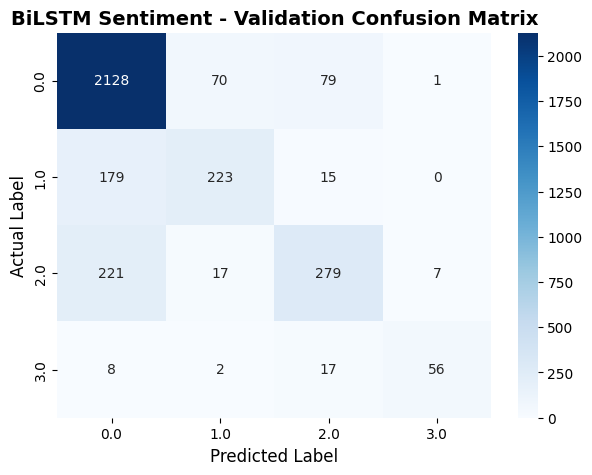


--- BiLSTM Sentiment (Test Evaluation) ---
              precision    recall  f1-score   support

           0     0.8261    0.9265    0.8734      4557
           1     0.7051    0.4850    0.5747       833
           2     0.6847    0.5091    0.5840      1045
           3     0.9324    0.7931    0.8571       174

    accuracy                         0.8013      6609
   macro avg     0.7871    0.6784    0.7223      6609
weighted avg     0.7913    0.8013    0.7896      6609



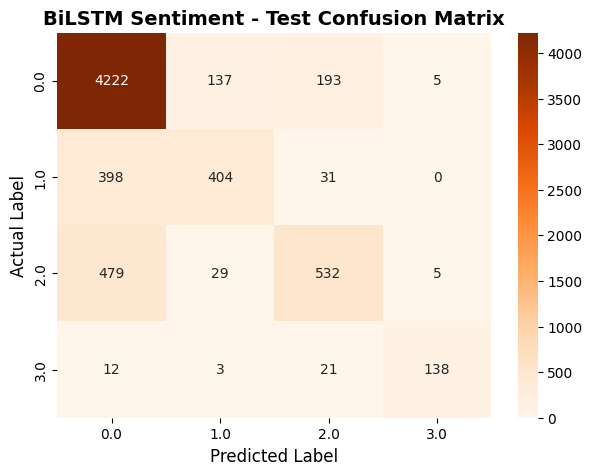


--- Baseline 2: BiLSTM (Topic) ---


Training:   0%|          | 0/360 [00:00<?, ?it/s]

Epoch 1/20
	Train Loss: 1.2609 | Val Loss: 1.1150 | Val F1-macro: 0.1951
	 -> New best F1! Saving model state.


Training:   0%|          | 0/360 [00:00<?, ?it/s]

Epoch 2/20
	Train Loss: 1.0329 | Val Loss: 0.9741 | Val F1-macro: 0.3141
	 -> New best F1! Saving model state.


...

Epoch 18/20
	Train Loss: 0.4872 | Val Loss: 0.7653 | Val F1-macro: 0.5698


Training:   0%|          | 0/360 [00:00<?, ?it/s]

Epoch 19/20
	Train Loss: 0.4669 | Val Loss: 0.7713 | Val F1-macro: 0.5694


Training:   0%|          | 0/360 [00:00<?, ?it/s]

Epoch 20/20
	Train Loss: 0.4392 | Val Loss: 0.8187 | Val F1-macro: 0.5508

--- Best Validation F1-macro: 0.5773 ---

--- BiLSTM Topic (Validation Evaluation) ---
              precision    recall  f1-score   support

           0     0.5946    0.5500    0.5714        40
           1     0.5075    0.3736    0.4304        91
           2     0.7677    0.8641    0.8131      1052
           3     0.8143    0.8833    0.8474      1440
           4     0.6584    0.4473    0.5327       237
           5     0.7600    0.4691    0.5802        81
           6     0.7077    0.3108    0.4319       148
           7     0.6053    0.2949    0.3966        78
           8     0.3485    0.3382    0.3433        68
           9     0.5417    0.5821    0.5612        67

    accuracy                         0.7608      3302
   macro avg     0.6306    0.5113    0.5508      3302
weighted avg     0.7510    0.7608    0.7470      3302



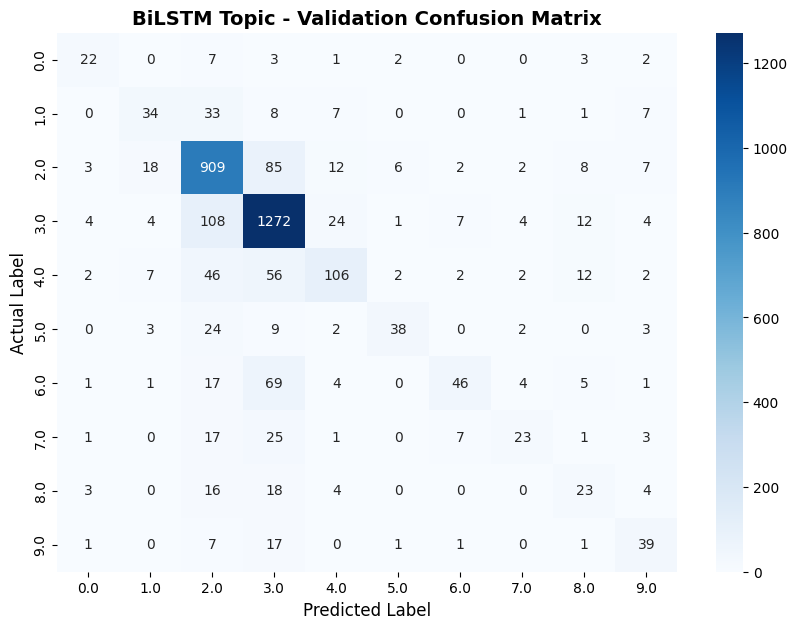


--- BiLSTM Topic (Test Evaluation) ---
              precision    recall  f1-score   support

           0     0.5114    0.5357    0.5233        84
           1     0.4667    0.3825    0.4204       183
           2     0.7819    0.8474    0.8133      2103
           3     0.8001    0.8868    0.8412      2879
           4     0.6376    0.3861    0.4809       474
           5     0.7010    0.4172    0.5231       163
           6     0.6149    0.3322    0.4314       298
           7     0.5517    0.2065    0.3005       155
           8     0.3576    0.3942    0.3750       137
           9     0.5510    0.6090    0.5786       133

    accuracy                         0.7516      6609
   macro avg     0.5974    0.4997    0.5288      6609
weighted avg     0.7389    0.7516    0.7368      6609



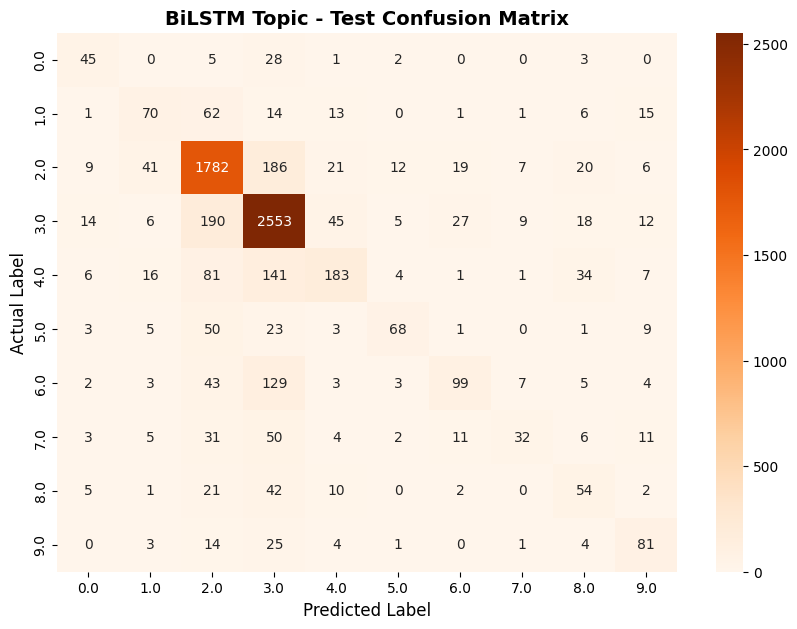


✓ Hoàn thành Baseline 2 (BiLSTM) bao gồm Confusion Matrix Heatmaps.


In [25]:
# (Code của Cell 24 - Cập nhật toàn bộ)

# Lấy nhãn sentiment để vẽ CM (giống Cell 14)
class_labels_sent = sorted(y_val_sent.unique()) 
# Lấy nhãn topic để vẽ CM (giống Cell 17)
class_labels_topic = sorted(y_val_topic.unique()) 

if word_vectors is not None:
    N_EPOCHS_LSTM = 20 # Giữ ở mức thấp (3-5) cho baseline
    criterion = nn.CrossEntropyLoss().to(device) # Cần criterion để evaluate
    
    # -----------------------------------------------
    # 1. Huấn luyện & Đánh giá Model Sentiment
    # -----------------------------------------------
    print("\n--- Baseline 2: BiLSTM (Sentiment) ---")
    num_sent_classes = len(train_df['sentiment'].unique())
    
    # Huấn luyện model
    best_sent_model = run_training_pipeline(BiLSTMClassifier, 
                                            train_sent_loader, 
                                            val_sent_loader, 
                                            num_sent_classes, 
                                            N_EPOCHS_LSTM)
    
    # (MỚI) Đánh giá model tốt nhất trên Validation
    print("\n--- BiLSTM Sentiment (Validation Evaluation) ---")
    val_loss, val_f1, val_report, val_labels, val_preds = evaluate(best_sent_model, val_sent_loader, criterion)
    print(val_report)
    baseline_results['bilstm_sentiment_val'] = val_f1

    # (MỚI) Vẽ Validation Confusion Matrix
    cm_val_sent = confusion_matrix(val_labels, val_preds)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm_val_sent, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_labels_sent, yticklabels=class_labels_sent)
    plt.title('BiLSTM Sentiment - Validation Confusion Matrix', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12); plt.ylabel('Actual Label', fontsize=12)
    plt.savefig(os.path.join(FIGURES_PATH, 'bilstm_sentiment_validation_cm.png'), dpi=300)
    plt.show()

    # (MỚI) Đánh giá model tốt nhất trên Test
    print("\n--- BiLSTM Sentiment (Test Evaluation) ---")
    test_loss, test_f1, test_report, test_labels, test_preds = evaluate(best_sent_model, test_sent_loader, criterion)
    print(test_report)
    baseline_results['bilstm_sentiment_test'] = test_f1

    # (MỚI) Vẽ Test Confusion Matrix
    cm_test_sent = confusion_matrix(test_labels, test_preds)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm_test_sent, annot=True, fmt='d', cmap='Oranges', 
                xticklabels=class_labels_sent, yticklabels=class_labels_sent)
    plt.title('BiLSTM Sentiment - Test Confusion Matrix', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12); plt.ylabel('Actual Label', fontsize=12)
    plt.savefig(os.path.join(FIGURES_PATH, 'bilstm_sentiment_test_cm.png'), dpi=300)
    plt.show()
    
    # -----------------------------------------------
    # 2. Huấn luyện & Đánh giá Model Topic
    # -----------------------------------------------
    print("\n--- Baseline 2: BiLSTM (Topic) ---")
    num_topic_classes = len(train_df['classification'].unique())
    
    # Huấn luyện model
    best_topic_model = run_training_pipeline(BiLSTMClassifier, 
                                             train_topic_loader, 
                                             val_topic_loader, 
                                             num_topic_classes, 
                                             N_EPOCHS_LSTM)

    # (MỚI) Đánh giá model tốt nhất trên Validation
    print("\n--- BiLSTM Topic (Validation Evaluation) ---")
    val_loss_t, val_f1_t, val_report_t, val_labels_t, val_preds_t = evaluate(best_topic_model, val_topic_loader, criterion)
    print(val_report_t)
    baseline_results['bilstm_topic_val'] = val_f1_t

    # (MỚI) Vẽ Validation Confusion Matrix
    cm_val_topic = confusion_matrix(val_labels_t, val_preds_t)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm_val_topic, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_labels_topic, yticklabels=class_labels_topic)
    plt.title('BiLSTM Topic - Validation Confusion Matrix', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12); plt.ylabel('Actual Label', fontsize=12)
    plt.savefig(os.path.join(FIGURES_PATH, 'bilstm_topic_validation_cm.png'), dpi=300)
    plt.show()

    # (MỚI) Đánh giá model tốt nhất trên Test
    print("\n--- BiLSTM Topic (Test Evaluation) ---")
    test_loss_t, test_f1_t, test_report_t, test_labels_t, test_preds_t = evaluate(best_topic_model, test_topic_loader, criterion)
    print(test_report_t)
    baseline_results['bilstm_topic_test'] = test_f1_t

    # (MỚI) Vẽ Test Confusion Matrix
    cm_test_topic = confusion_matrix(test_labels_t, test_preds_t)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm_test_topic, annot=True, fmt='d', cmap='Oranges', 
                xticklabels=class_labels_topic, yticklabels=class_labels_topic)
    plt.title('BiLSTM Topic - Test Confusion Matrix', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12); plt.ylabel('Actual Label', fontsize=12)
    plt.savefig(os.path.join(FIGURES_PATH, 'bilstm_topic_test_cm.png'), dpi=300)
    plt.show()

else:
    print("\nBỏ qua Baseline 2 (BiLSTM) vì không tải được embeddings.")
    baseline_results['bilstm_sentiment_val'] = 0.0
    baseline_results['bilstm_sentiment_test'] = 0.0
    baseline_results['bilstm_topic_val'] = 0.0
    baseline_results['bilstm_topic_test'] = 0.0

print("\n✓ Hoàn thành Baseline 2 (BiLSTM) bao gồm Confusion Matrix Heatmaps.")

In [26]:
print("\n=============================================")
print("TỔNG KẾT KẾT QUẢ BASELINE (Validation F1-macro)")
print("=============================================")

# Tạo DataFrame để xem
results_df = pd.DataFrame({
    'Sentiment': {
        'SVM': baseline_results.get('svm_sentiment_test', 0.0),
        'BiLSTM': baseline_results.get('bilstm_sentiment_test', 0.0)
    },
    'Topic': {
        'SVM': baseline_results.get('svm_topic_test', 0.0),
        'BiLSTM': baseline_results.get('bilstm_topic_test', 0.0)
    }
})

print(results_df)

# Lưu file metrics
METRICS_PATH = os.path.join(KAGGLE_WORKING_PATH, 'baseline_metrics.json')
with open(METRICS_PATH, 'w') as f:
    json.dump(baseline_results, f, indent=2)
    
print(f"\n✓ Baseline metrics đã được lưu vào: {METRICS_PATH}")


TỔNG KẾT KẾT QUẢ BASELINE (Validation F1-macro)
        Sentiment     Topic
SVM      0.702603  0.564595
BiLSTM   0.722298  0.528763

✓ Baseline metrics đã được lưu vào: /kaggle/working/baseline_metrics.json
